# AAV9 fitting protocol — how much information is really in the read-out?

Two parts:

1. **Repeatability check**: run the SAME `ProtocolV3` config (real AAV9 `F_viab`/`J_viab`, same
   68,776-sequence library) 5 independent times (fresh stochastic noise only) and look at how
   correlated those 5 runs are with EACH OTHER. This is the simulated protocol's own noise
   ceiling at that config.
2. **Hyperparameter search**: search `(mu, T_viab, noise_viab, D)` for a protocol configuration
   whose simulated noise level imitates the REAL experiment's -- measured via each one's
   correlation to the SAME deterministic GT score (`compute_score(F_viab, J_viab)`, no protocol
   noise at all), so the simulated protocol is asked to match the real experiment's apparent
   fidelity to the GT model (`R_REAL`), not to reproduce its exact noisy values directly
   (unreachable given part 1's ~0.994 self-consistency ceiling on this real, wide-dynamic-range
   library -- see part 2 for why).


## 0. Setup

In [1]:
import sys, os

# This notebook lives in "Modelization_V1/notebooks/aav_viability_test/", two levels below
# analysisV1.py / sequence_classesV1.py -- same sys.path convention as AAV9_profile_model.ipynb.
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from itertools import combinations
from tqdm.auto import tqdm

from analysisV1 import AA_LABELS, pearson
from sequence_classesV1 import ProtocolV3
from initialize_weights import (
    load_F_viab_aav9_mlp, load_J_viab_aav9_mlp, NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV9 fitting protocol 1.0"


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Real AAV9 data: sequences + real `target`

In [2]:
df = pd.read_csv("aav9.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")

lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
assert int(lengths[0]) == NUM_POSITIONS

# error is a constant 0.1 placeholder across all 68,776 rows, not a real per-sequence measurement
# uncertainty -- confirmed below, this is why part 2 can't calibrate against it directly.
print(f"unique `error` values: {df['error'].unique()}")

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes   = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix  = lut[seq_bytes].reshape(len(df), NUM_POSITIONS)
real_target = df["target"].to_numpy()

sequences = jnp.asarray(seq_matrix)
d0        = sequences.shape[0]

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"d0 = {d0:,} real AAV9 library sequences")


68,776 variants, columns: ['sequence', 'target', 'error']
unique `error` values: [0.1]
seq_matrix shape: (68776, 7)  (num_sequences, num_positions)
d0 = 68,776 real AAV9 library sequences


## 2. Ground-truth weights + baseline protocol config

`F_viab`/`J_viab` are the ProfileMLP recovery from `AAV9_profile_model.ipynb` (section 3b),
fit on this exact `aav9.csv` dataset -- so they're already in the right amino-acid/position
convention for `seq_matrix` above.

`F_sel`/`J_sel` are set to zero: `loop_DE()` computes `lambda0p`/`lambda2p` (-> `target1`, the
viability log-enrichment we compare against `aav9.csv`'s real `target`) BEFORE `selectivity()`
is ever called, so `F_sel`/`J_sel` cannot influence `target1` at all. Zero makes that explicit
instead of implying a random permutation of them would matter here.

Baseline config is the project's established "best realistic" operating point (see
`mu_HEK_multiplicity_sweep.ipynb` / `T_viab_sweep.ipynb` / `noise_viab_sweep.ipynb`):
`mu=50`, `T_viab=0.8`, `noise_viab=0.5`, `D=1e9`. Part 1 checks THIS config's own repeatability;
part 2 then searches around it.

In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

F_sel = jnp.zeros_like(F_viab)
J_sel = jnp.zeros_like(J_viab)

RHO_REF          = 1e-3
MU_FIXED         = 50
T_VIAB_FIXED     = 0.8
NOISE_VIAB_FIXED = 0.5
D_FIXED          = 1e9
DILUTION_FACTOR  = 10
T_SEL_FIXED      = 1.0   # unused by target1, kept at the project default
eps              = 1.0

N1_FIXED = MU_FIXED * d0 / RHO_REF
N0_FIXED = N1_FIXED * 10

protocol = ProtocolV3(multinomialNGS=True, N0=N0_FIXED, N1=N1_FIXED,
        dilution_factor=DILUTION_FACTOR, sequences=sequences, D=D_FIXED,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_FIXED, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
        )

print(f"mu = {protocol._rho * protocol.N1 / d0:.2f}   N1={N1_FIXED:.3e}   N0={N0_FIXED:.3e}")


mu = 50.00   N1=3.439e+09   N0=3.439e+10


### 2b. GT score distribution across the real AAV9 library

`viab_score_GT = compute_score(F_viab, J_viab)` -- the deterministic F+J score for every real
sequence, with NO protocol simulation and no noise at all. Reused later (part 2) as the
reference everything else is compared against.

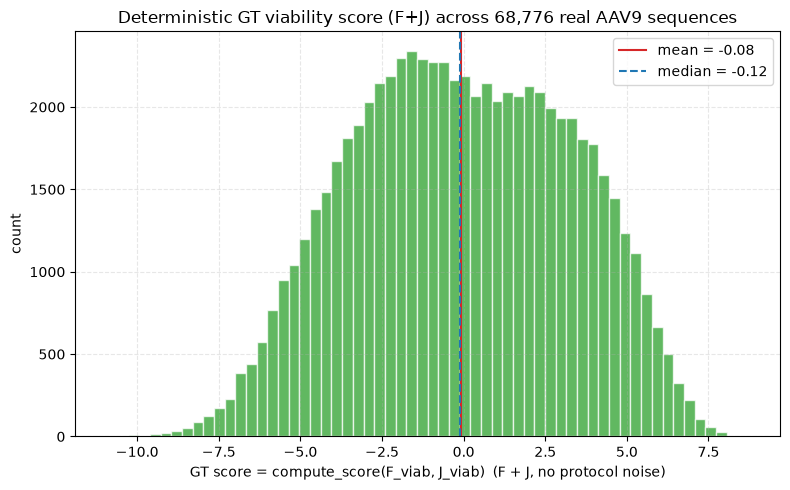

GT score: min=-10.92  max=8.71  mean=-0.08  std=3.34


In [4]:
viab_score_GT = np.asarray(protocol.compute_score(F_viab, J_viab))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(viab_score_GT, bins=60, color="tab:green", alpha=0.75, edgecolor="white")
ax.axvline(viab_score_GT.mean(), color="tab:red", linestyle="-", label=f"mean = {viab_score_GT.mean():.2f}")
ax.axvline(np.median(viab_score_GT), color="tab:blue", linestyle="--", label=f"median = {np.median(viab_score_GT):.2f}")
ax.set_xlabel("GT score = compute_score(F_viab, J_viab)  (F + J, no protocol noise)")
ax.set_ylabel("count")
ax.set_title(f"Deterministic GT viability score (F+J) across {d0:,} real AAV9 sequences")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"GT score: min={viab_score_GT.min():.2f}  max={viab_score_GT.max():.2f}  "
      f"mean={viab_score_GT.mean():.2f}  std={viab_score_GT.std():.2f}")


## 3. Part 1 — repeatability of the baseline config

Reusing the SAME `protocol` object across several `loop_DE()` calls advances its internal PRNG
key each time (same convention as `mu_HEK_multiplicity_sweep.ipynb`'s `N_REPEATS`), so 5 calls
give 5 independent stochastic draws of the IDENTICAL experiment. `lambda0` is explicitly reset
before every call -- `loop_DE()` depletes it in place (`_ngs_and_deplete`), so without the reset,
repeat 2 would start from repeat 1's already-depleted library instead of a fresh one.

In [5]:
def viability_target1(protocol, eps=eps):
    """Runs one loop_DE() round and returns target1 = log((lambda2p+eps)/(lambda0p+eps)), the
    viability log-enrichment estimated from NGS reads only (same formula as every sibling sweep
    notebook / RegressionV1.build_multi_round_dataset). Resets lambda0 first, since loop_DE()
    depletes it in place and repeated calls must start from a fresh library each time."""
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    _bio_row, ngs_row = protocol.loop_DE()
    lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
    return np.log((lambda2p + eps) / (lambda0p + eps))

N_REPEATS_PART1 = 5
target1_replicates = [viability_target1(protocol)
                       for _ in tqdm(range(N_REPEATS_PART1), desc="Part 1 repeats")]

pairwise_r = np.array([pearson(a, b) for a, b in combinations(target1_replicates, 2)])

print(f"{len(pairwise_r)} pairwise correlations among {N_REPEATS_PART1} identical-config runs")
print(f"mean r = {pairwise_r.mean():.3f}   std = {pairwise_r.std():.3f}   "
      f"min = {pairwise_r.min():.3f}   max = {pairwise_r.max():.3f}")


Part 1 repeats: 100%|██████████| 5/5 [01:44<00:00, 20.92s/it]

10 pairwise correlations among 5 identical-config runs
mean r = 0.993   std = 0.000   min = 0.993   max = 0.993


### 3b. Histogram of the 10 pairwise correlations

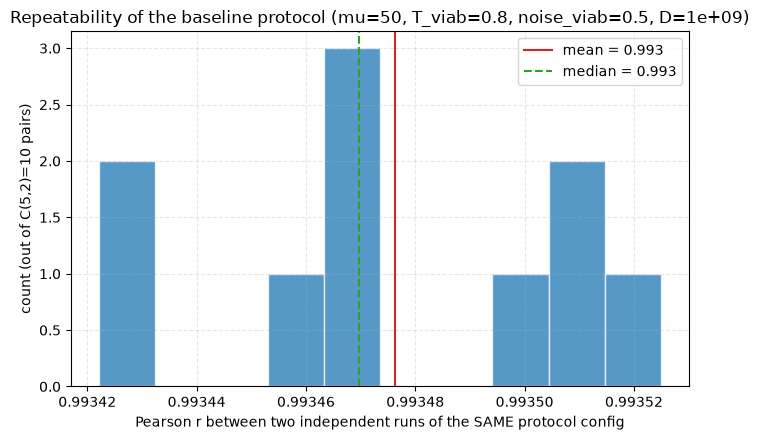

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(pairwise_r, bins=10, color="tab:blue", alpha=0.75, edgecolor="white")
ax.axvline(pairwise_r.mean(), color="tab:red", linestyle="-", label=f"mean = {pairwise_r.mean():.3f}")
ax.axvline(np.median(pairwise_r), color="tab:green", linestyle="--", label=f"median = {np.median(pairwise_r):.3f}")
ax.set_xlabel("Pearson r between two independent runs of the SAME protocol config")
ax.set_ylabel("count (out of C(5,2)=10 pairs)")
ax.set_title(f"Repeatability of the baseline protocol (mu={MU_FIXED}, T_viab={T_VIAB_FIXED}, "
             f"noise_viab={NOISE_VIAB_FIXED}, D={D_FIXED:.0e})")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 4. Part 2 — hyperparameter search: does the simulated protocol imitate the real experiment's stochasticity?

**Reference point**: `viab_score_GT = compute_score(F_viab, J_viab)` is the fully deterministic
score (no protocol simulation, no noise at all) for every real AAV9 sequence. Comparing anything
noisy to THIS gives a clean measure of how much noise corrupts it.

**`R_REAL`**: `pearson(real_target, viab_score_GT)` -- how much the REAL experiment's own noise
degrades agreement with the GT model. This is the number we want the SIMULATED protocol to
reproduce -- not by matching `real_target` directly (unreachable: part 1 showed even two runs of
the SAME simulated config only agree with each other at r=0.994, an implied `r(sim, GT) <~
sqrt(0.994) ~ 0.997` ceiling that real data, with its own independent noise on top, has no reason
to reach), but by making `r(simulated target1, viab_score_GT)` land at `R_REAL` too.

**"50% of cases"**: for a candidate `(mu, T_viab, noise_viab, D)`, run several stochastic repeats
and call a repeat a "success" if `r(target1_repeat, viab_score_GT) >= R_REAL` -- i.e. that repeat
is at least as faithful to the GT model as the real experiment apparently is. Searching for
`success_fraction ~= 50%` is the same thing as searching for hyperparameters whose simulated
fidelity has `R_REAL` as its MEDIAN -- the natural definition of "the simulated protocol's
stochasticity imitates the real experiment's".

**Caveat (unchanged)**: `F_viab`/`J_viab` were fit FROM `real_target` (ProfileMLP,
`AAV9_profile_model.ipynb`), so `R_REAL` is not an independent ground-truth check -- it's a
self-consistent proxy for "how noisy the real process looks, relative to the best model we have
of it".

**Search strategy (unchanged)**: random search over `(mu, T_viab, noise_viab, D)`, log-uniform/
uniform ranges spanning each hyperparameter's own established sweep grid (a full 10x15x8x9 =
10,800-combo grid is impractical here -- each repeat costs ~20s on this 68,776-sequence real
library, see part 1's timing).


In [9]:
R_REAL = pearson(real_target, viab_score_GT)  # viab_score_GT computed in section 2b
baseline_ceiling = float(np.sqrt(np.median(pairwise_r)))
print(f"R_REAL = r(real aav9 target, deterministic GT score) = {R_REAL:.3f}")
print(f"baseline config's own implied r(sim, GT) ceiling ~= sqrt({np.median(pairwise_r):.3f}) = {baseline_ceiling:.3f}")
print("(if R_REAL << baseline_ceiling, the real experiment is noisier than the current defaults -- "
      "search should land on higher noise_viab / lower mu / lower D than the baseline)")

# Log-uniform / uniform search ranges, spanning each hyperparameter's own established sweep grid
# (mu_HEK_multiplicity_sweep.ipynb / T_viab_sweep.ipynb / noise_viab_sweep.ipynb /
# D_sequencing_depth_sweep.ipynb) -- a full 10x15x8x9 grid product (10,800 combos) is wasteful,
# a random search covers the same 4D space far more cheaply. D's upper bound is capped at the
# project's baseline D=1e9 (not D_GRID's 1e10) -- deeper sequencing than the established
# baseline isn't a realistic lab target for this search.
SEARCH_RANGES = dict(
    mu          = (0.01, 1000.0),   # log-uniform, spans MU_GRID
    T_viab      = (0.1, 50.0),      # log-uniform, spans T_VIAB_GRID
    noise_viab  = (0.0, 8.0),       # uniform, spans NOISE_GRID
    D           = (1e6, 1e9),       # log-uniform, capped at the baseline D
)
N_CANDIDATES     = 12   # ~20s per repeat on this 68,776-seq pool -- tune before running
N_REPEATS_SEARCH = 3
rng_search = np.random.default_rng(42)

def sample_candidate(rng):
    lo, hi = SEARCH_RANGES["mu"];         mu         = 10 ** rng.uniform(np.log10(lo), np.log10(hi))
    lo, hi = SEARCH_RANGES["T_viab"];     T_viab     = 10 ** rng.uniform(np.log10(lo), np.log10(hi))
    lo, hi = SEARCH_RANGES["noise_viab"]; noise_viab = rng.uniform(lo, hi)
    lo, hi = SEARCH_RANGES["D"];          D          = 10 ** rng.uniform(np.log10(lo), np.log10(hi))
    return dict(mu=mu, T_viab=T_viab, noise_viab=noise_viab, D=D)

def run_candidate(protocol, mu, T_viab, noise_viab, D, n_repeats):
    """Runs n_repeats stochastic loop_DE()s at this hyperparameter combo and returns, for each
    repeat, r(simulated target1, viab_score_GT) -- how faithful THAT repeat is to the
    deterministic GT model, directly comparable to R_REAL."""
    protocol.N1          = float(mu * d0 / RHO_REF)
    protocol.N0          = float(protocol.N1 * 10)
    protocol._T_viab     = float(T_viab)
    protocol.noise_viab  = float(noise_viab)
    protocol.D           = float(D)
    r_list = [pearson(viability_target1(protocol), viab_score_GT) for _ in range(n_repeats)]
    return np.array(r_list)

candidates = []
for _ in tqdm(range(N_CANDIDATES), desc="Part 2 random search"):
    params = sample_candidate(rng_search)
    r_list = run_candidate(protocol, n_repeats=N_REPEATS_SEARCH, **params)
    candidates.append(dict(**params, r_mean=r_list.mean(), r_std=r_list.std(),
                            success_fraction=float(np.mean(r_list >= R_REAL))))

candidates_df = pd.DataFrame(candidates)
candidates_df.head()


R_REAL = r(real aav9 target, deterministic GT score) = 0.853
baseline config's own implied r(sim, GT) ceiling ~= sqrt(0.993) = 0.997
(if R_REAL << baseline_ceiling, the real experiment is noisier than the current defaults -- search should land on higher noise_viab / lower mu / lower D than the baseline)


Part 2 random search:   0%|          | 0/12 [00:07<?, ?it/s]


KeyboardInterrupt: 

### 4b. Candidates closest to `R_REAL`

Ranked by `|r_mean - R_REAL|` directly, not by the boolean `success_fraction` -- with only
`N_REPEATS_SEARCH=3` repeats and `r_std` typically ~0.001-0.005, `success_fraction` only takes
values in `{0, 1/3, 2/3, 1}`, so most candidates tie at `dist_to_50pct=0.5` and a tie-break on
tied rows would pick arbitrarily among them instead of the one whose `r_mean` is actually
closest to `R_REAL`.

In [8]:
candidates_df["dist_to_R_REAL"] = (candidates_df["r_mean"] - R_REAL).abs()
top_candidates = candidates_df.sort_values("dist_to_R_REAL").head(15).reset_index(drop=True)
top_candidates


NameError: name 'candidates_df' is not defined

### 4c. Confirm the best candidate with more repeats

In [ ]:
best = top_candidates.iloc[0]
N_REPEATS_CONFIRM = 15

r_confirm = run_candidate(protocol, mu=best["mu"], T_viab=best["T_viab"],
                           noise_viab=best["noise_viab"], D=best["D"], n_repeats=N_REPEATS_CONFIRM)
success_fraction_confirm = float(np.mean(r_confirm >= R_REAL))

print(f"best candidate: mu={best['mu']:.3g}  T_viab={best['T_viab']:.3g}  "
      f"noise_viab={best['noise_viab']:.3g}  D={best['D']:.3g}")
print(f"R_REAL = {R_REAL:.3f}")
print(f"confirmed over {N_REPEATS_CONFIRM} repeats: "
      f"success_fraction={success_fraction_confirm:.2f}  "
      f"r(sim, GT) = {r_confirm.mean():.3f} +/- {r_confirm.std():.3f}")


best candidate: mu=145  T_viab=14.9  noise_viab=3.1  D=7.33e+06
R_REAL = 0.853
confirmed over 15 repeats: success_fraction=0.00  r(sim, GT) = 0.807 +/- 0.001


### 4d. Does the match rate vary systematically with each hyperparameter?

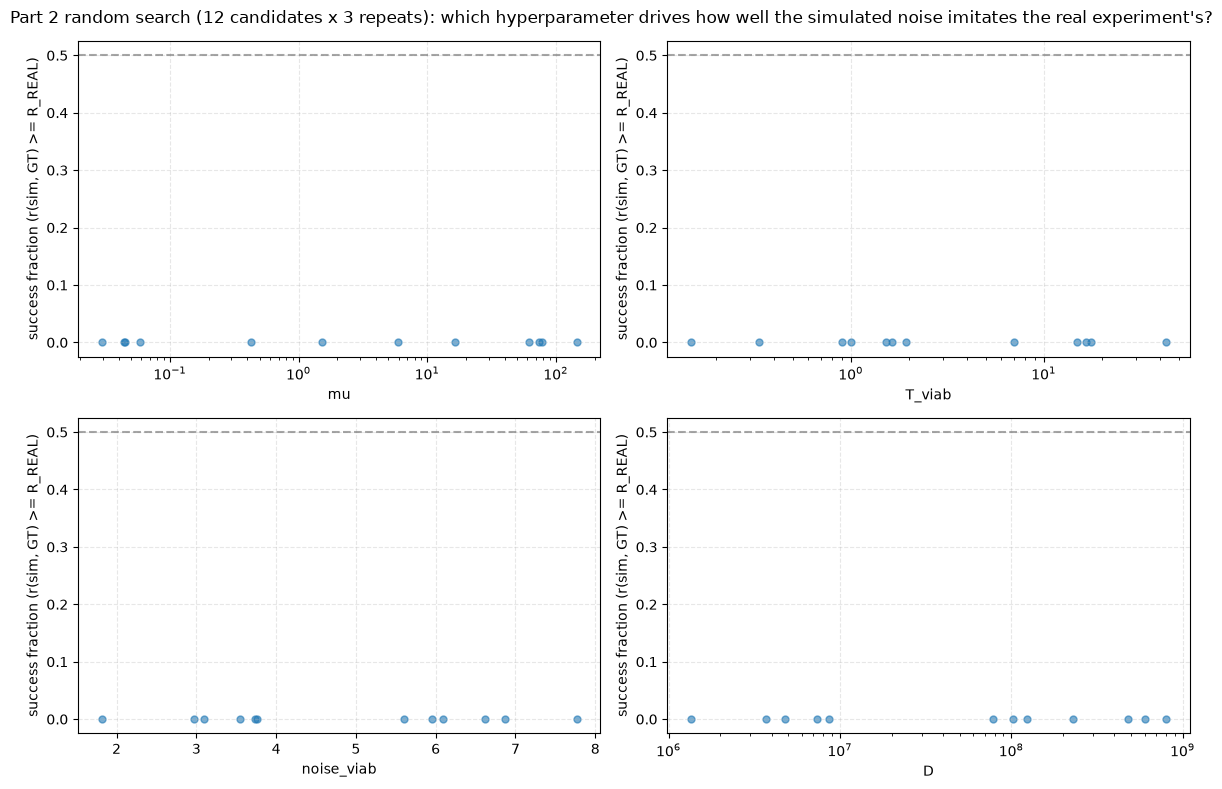

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
specs = [("mu", True), ("T_viab", True), ("noise_viab", False), ("D", True)]
for ax, (col, logscale) in zip(axes.flat, specs):
    ax.scatter(candidates_df[col], candidates_df["success_fraction"], alpha=0.6, s=25)
    if logscale:
        ax.set_xscale("log")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel("success fraction (r(sim, GT) >= R_REAL)")
    ax.grid(True, linestyle="--", alpha=0.3)
fig.suptitle(f"Part 2 random search ({N_CANDIDATES} candidates x {N_REPEATS_SEARCH} repeats): "
             f"which hyperparameter drives how well the simulated noise imitates the real experiment's?")
fig.tight_layout()
plt.show()

### 4e. Histograms for every tested candidate (diagnosing the log-enrichment=0 spike)

A single best-candidate overlay can show a large spike at `log enrichment = 0` -- that isn't
noise, it's `target1 = log((0+eps)/(0+eps)) = log(1) = 0` for every sequence that got ZERO NGS
reads at BOTH checkpoints (`lambda0p` and `lambda2p`), i.e. sequences the simulated protocol
never sampled at all. A high `frac(target1=0)` means the correlation-based search matched
`R_REAL` partly by making most of the library invisible, not by genuinely reproducing the real
experiment's per-sequence noise. Plotting every tested candidate (not just the one
auto-selected by correlation) makes this failure mode visible across the whole search, so a
config can be picked that's close on BOTH correlation AND distribution shape.

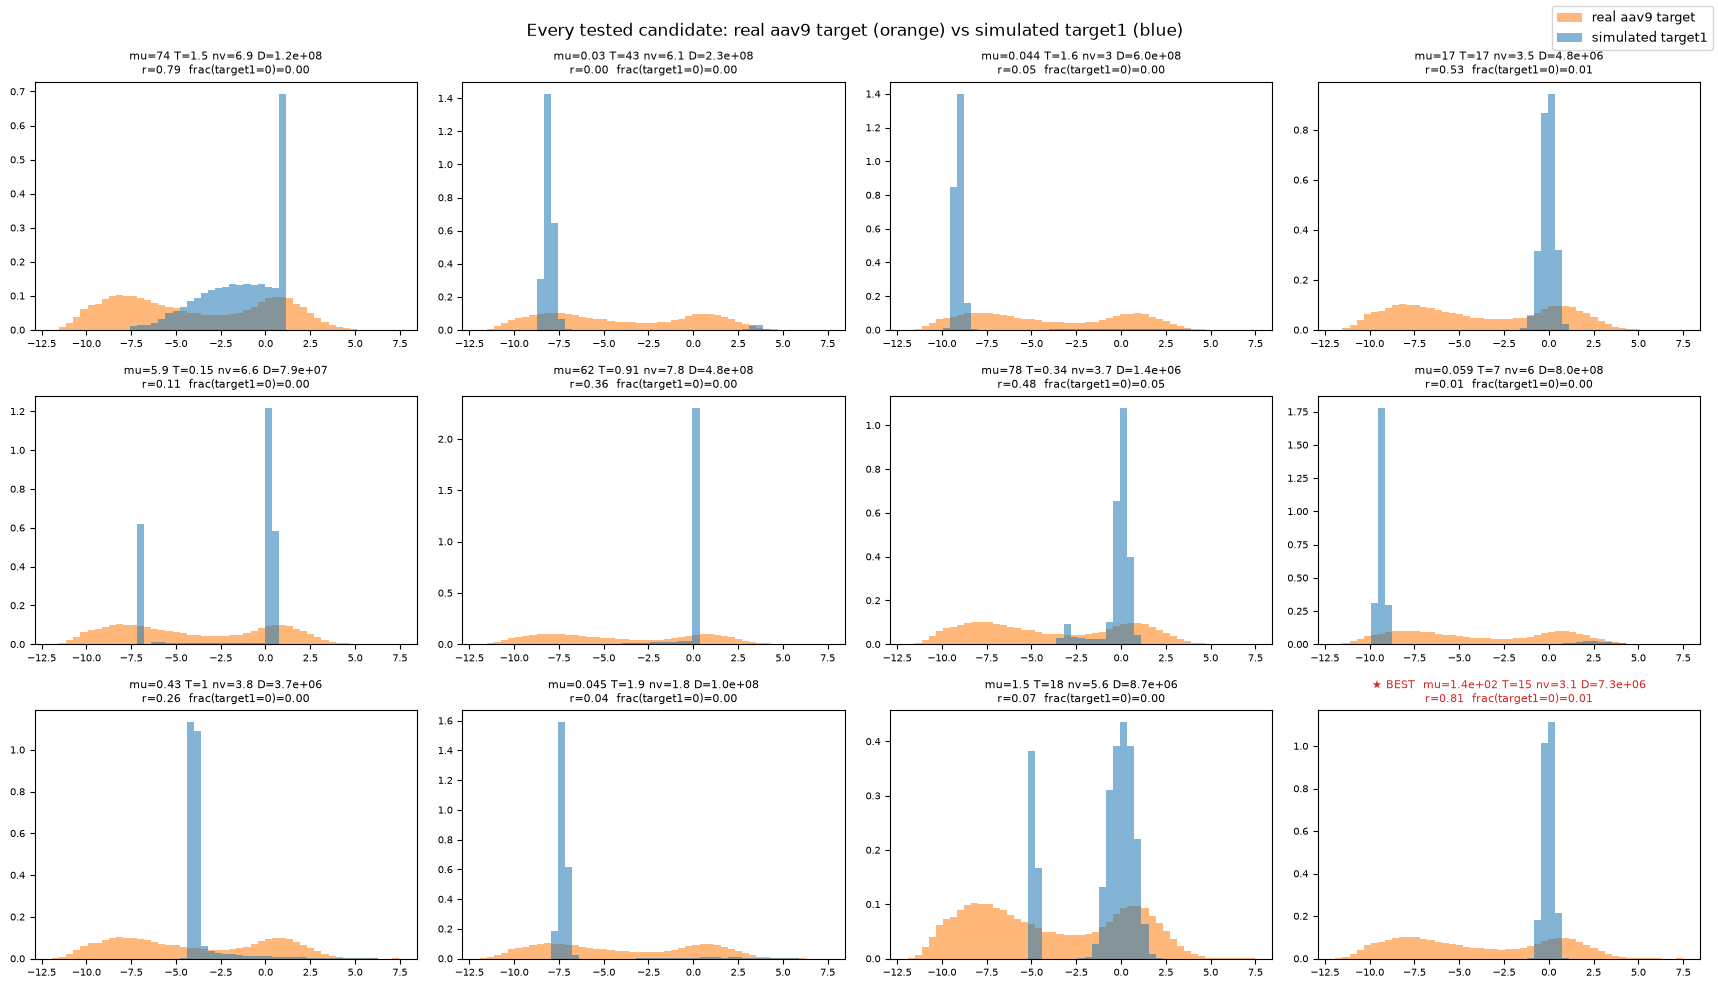

In [ ]:
N_COLS = 4
N_ROWS = int(np.ceil(len(candidates_df) / N_COLS))
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(4.3 * N_COLS, 3.3 * N_ROWS), squeeze=False)
bins = np.linspace(real_target.min(), real_target.max(), 50)

for idx, row in candidates_df.iterrows():
    protocol.N1          = float(row["mu"] * d0 / RHO_REF)
    protocol.N0          = float(protocol.N1 * 10)
    protocol._T_viab     = float(row["T_viab"])
    protocol.noise_viab  = float(row["noise_viab"])
    protocol.D           = float(row["D"])
    target1_cand = viability_target1(protocol)
    frac_zero = float(np.mean(target1_cand == 0.0))

    is_best = np.isclose(row["mu"], best["mu"]) and np.isclose(row["T_viab"], best["T_viab"]) \
              and np.isclose(row["noise_viab"], best["noise_viab"]) and np.isclose(row["D"], best["D"])

    ax = axes[idx // N_COLS, idx % N_COLS]
    ax.hist(real_target,  bins=bins, alpha=0.55, density=True, color="tab:orange")
    ax.hist(target1_cand, bins=bins, alpha=0.55, density=True, color="tab:blue")
    title = (f"{'★ BEST  ' if is_best else ''}mu={row['mu']:.2g} T={row['T_viab']:.2g} "
             f"nv={row['noise_viab']:.2g} D={row['D']:.1e}\n"
             f"r={row['r_mean']:.2f}  frac(target1=0)={frac_zero:.2f}")
    ax.set_title(title, fontsize=8, color="tab:red" if is_best else "black")
    ax.tick_params(labelsize=7)

for idx in range(len(candidates_df), N_ROWS * N_COLS):
    axes[idx // N_COLS, idx % N_COLS].axis("off")

fig.legend(["real aav9 target", "simulated target1"], loc="upper right", fontsize=9)
fig.suptitle("Every tested candidate: real aav9 target (orange) vs simulated target1 (blue)")
fig.tight_layout()
plt.show()

# Restore protocol to the documented baseline config, so any cell re-run after this one doesn't
# silently inherit the last-plotted candidate's hyperparameters instead.
protocol.N1, protocol.N0 = N1_FIXED, N0_FIXED
protocol._T_viab          = T_VIAB_FIXED
protocol.noise_viab       = NOISE_VIAB_FIXED
protocol.D                = D_FIXED


## How to read this

- **Part 1's histogram** is the simulated protocol's own noise ceiling at the baseline config:
  `r(sim, sim) = 0.994` there implies `r(sim, deterministic GT) <~ sqrt(0.994) ~ 0.997` -- very
  little noise relative to signal, on this real, wide-dynamic-range library.
- **`R_REAL`** (part 2) is the real experiment's own apparent fidelity to the GT model. If
  `R_REAL` is well below the baseline's own ~0.997, the real protocol is noisier than our
  default simulation -- part 2's search should land on hyperparameters with MORE noise (higher
  `noise_viab`, lower `mu`/`D`) than the current defaults, not less. If `R_REAL` is close to
  ~0.997, the baseline is already about right.
- **Part 2's scatter plots** show which of `mu`/`T_viab`/`noise_viab`/`D` the match rate is most
  sensitive to -- a flat cloud for a given hyperparameter means it isn't the bottleneck; a clear
  trend means it's worth narrowing the search range around it (or sweeping it on its own, the
  way the sibling notebooks already do for the GT<->protocol correlation).
- **The per-candidate histogram grid (4e)** is the sanity check `success_fraction`/`R_REAL`
  alone can't give: matching correlation doesn't guarantee matching distribution SHAPE, and a
  high `frac(target1=0)` on a panel means that candidate is "winning" on correlation partly by
  making most of the library undetected (zero reads at both NGS checkpoints), not by imitating
  realistic per-sequence noise. Prefer a candidate with both a decent `r` AND a low
  `frac(target1=0)`, even if it isn't the `★ BEST` one the automatic ranking picked.

## 5. Manual playground: tweak hyperparameters and weights by hand

Edit the block at the top of the cell below (hyperparameters, and/or `F_VIAB_MANUAL`/
`J_VIAB_MANUAL` if you want to try different weights) and re-run -- it always sets `protocol`'s
full state from these variables, so nothing is left over between runs to worry about.

`F_sel`/`J_sel` aren't included here: as throughout this notebook, `loop_DE()` computes
`lambda0p`/`lambda2p` (-> `target1`) BEFORE `selectivity()` runs, so they can't affect what's
plotted below regardless of their value.

In [18]:
print(sequences.shape)

# ---- Edit these, then re-run this cell ----
MU_MANUAL         = 50.0
RHO_REF           = 1e-4
T_VIAB_MANUAL     = 0.8
NOISE_VIAB_MANUAL = 1
D_MANUAL          = 1e9
F_VIAB_MANUAL     = F_viab   # swap for another (num_amino_acids, num_positions) array to test different weights
J_VIAB_MANUAL     = J_viab   # swap for another (num_positions, num_positions, num_amino_acids, num_amino_acids) array
# --------------------------------------------

protocol.F_viab      = F_VIAB_MANUAL
protocol.J_viab      = J_VIAB_MANUAL
protocol.N1          = float(MU_MANUAL * d0 / RHO_REF)
protocol.N0          = float(protocol.N1 * 150)
protocol._T_viab     = float(T_VIAB_MANUAL)
protocol.noise_viab  = float(NOISE_VIAB_MANUAL)
protocol.D           = float(D_MANUAL)

print(f"Number of plasmids per sequence : {protocol.N0/d0}")
print(f"Expected number of count per sequence : {protocol.D/d0}")
print(f"log enrichment for the dying variants : {-np.log(protocol.D/d0)}")

(68776, 7)
Number of plasmids per sequence : 75000000.0
Expected number of count per sequence : 14539.955798534373
log enrichment for the dying variants : -9.58465571109213


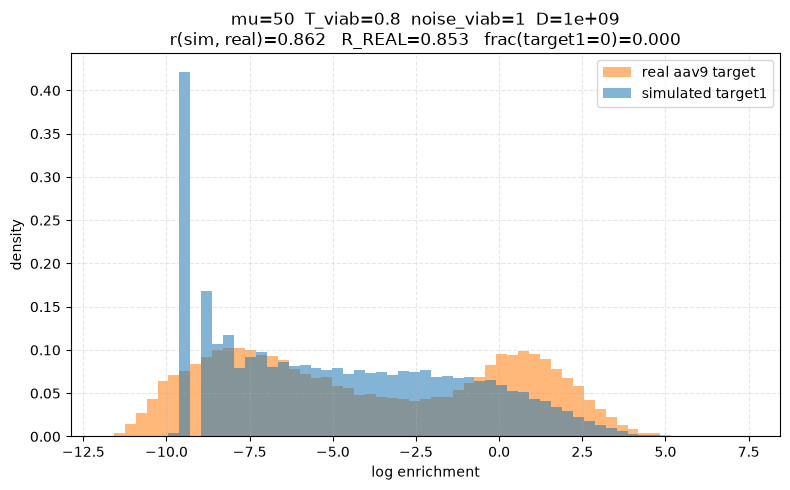

In [19]:
target1_manual   = viability_target1(protocol)
r_manual         = pearson(target1_manual, real_target)
frac_zero_manual = float(np.mean(target1_manual == 0.0))

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(min(real_target.min(), target1_manual.min()),
                    max(real_target.max(), target1_manual.max()), 60)
ax.hist(real_target,    bins=bins, alpha=0.55, density=True, color="tab:orange", label="real aav9 target")
ax.hist(target1_manual, bins=bins, alpha=0.55, density=True, color="tab:blue",   label="simulated target1")
ax.set_xlabel("log enrichment")
ax.set_ylabel("density")
ax.set_title(f"mu={MU_MANUAL:.3g}  T_viab={T_VIAB_MANUAL:.3g}  noise_viab={NOISE_VIAB_MANUAL:.3g}  D={D_MANUAL:.3g}\n"
             f"r(sim, real)={r_manual:.3f}   R_REAL={R_REAL:.3f}   frac(target1=0)={frac_zero_manual:.3f}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 6. Overlay: GT score vs the manual playground's simulated log enrichment

`viab_score_GT` (section 2b, deterministic F+J, no noise) vs `target1_manual` (section 5, one
stochastic `loop_DE()` run at the hand-picked hyperparameters above) -- shows how much the
protocol's noise/`exp(score/T_viab)` transform reshapes the raw score distribution into the
observed log-enrichment distribution (e.g. does it introduce the floor-effect pileup discussed
earlier, compress the spread, shift the modes...).

r(simulated target1, GT score) = -0.593   (unaffected by the T_viab rescaling -- Pearson r is invariant to dividing by a positive constant)
R_REAL = 0.853   (target this should land near, per section 4)


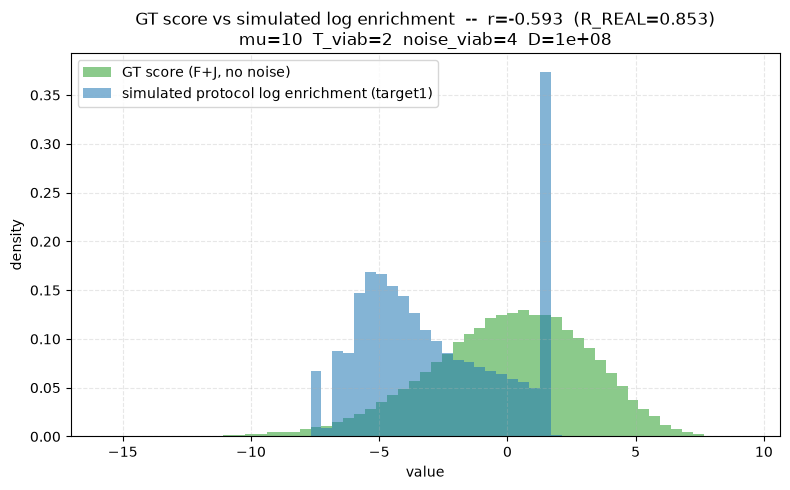

In [91]:
r_manual_vs_GT = pearson(target1_manual, viab_score_GT)
print(f"r(simulated target1, GT score) = {r_manual_vs_GT:.3f}   "
      f"(unaffected by the T_viab rescaling -- Pearson r is invariant to dividing by a positive constant)")
print(f"R_REAL = {R_REAL:.3f}   (target this should land near, per section 4)")

fig, ax = plt.subplots(figsize=(8, 5))
bins_score = np.linspace(min(viab_score_GT.min(), target1_manual.min()),
                          max(viab_score_GT.max(), target1_manual.max()), 60)
ax.hist(viab_score_GT,  bins=bins_score, alpha=0.55, density=True, color="tab:green", label="GT score (F+J, no noise)")
ax.hist(target1_manual, bins=bins_score, alpha=0.55, density=True, color="tab:blue",  label="simulated protocol log enrichment (target1)")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title(f"GT score vs simulated log enrichment  --  r={r_manual_vs_GT:.3f}  (R_REAL={R_REAL:.3f})\n"
             f"mu={MU_MANUAL:.3g}  T_viab={T_VIAB_MANUAL:.3g}  noise_viab={NOISE_VIAB_MANUAL:.3g}  D={D_MANUAL:.3g}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 7. ProfileMLP trained on 25,000 real AAV9 variants -- held-out test predictions

Same architecture/training convention as `AAV9_profile_model.ipynb` (one-hot 7x20=140 input, 2
hidden layers with BatchNorm+Dropout+GELU, AdamW + cosine-decay LR + early stopping) -- but here
the split is a plain 25,000-train / rest-test, not that notebook's original 50/50.

Trains directly on the REAL `target` column (not a simulated `target1`): a genuine recovery
benchmark for a plain MLP given only sequence + the real noisy NGS-derived label, evaluated on
sequences it never saw during training.

In [79]:
from sklearn.model_selection import train_test_split
from flax import nnx
from typing import Optional
import optax

N_TRAIN_MLP = 25_000

# One-hot: (d0, L) integer indices -> (d0, L*A) indicator features, same convention as
# AAV9_profile_model.ipynb -- gives the network the categorical amino-acid structure for free.
seq_oh = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix].reshape(d0, -1)

idx_train_mlp, idx_test_mlp = train_test_split(np.arange(d0), train_size=N_TRAIN_MLP, random_state=0)
y_train_mlp, y_test_mlp         = real_target[idx_train_mlp], real_target[idx_test_mlp]
X_train_full_mlp, X_test_mlp    = seq_oh[idx_train_mlp],       seq_oh[idx_test_mlp]

print(f"train: {len(idx_train_mlp):,}   test: {len(idx_test_mlp):,}")


train: 25,000   test: 43,776


In [80]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Same architecture as AAV9_profile_model.ipynb:
    Linear + BatchNorm + Dropout + gelu, twice, then a scalar output head.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [81]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


In [82]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp = split_train_val(X_train_full_mlp, y_train_mlp, val_frac=0.15, seed=0)
print(f"ProfileMLP -- train: {len(Xtr_mlp):,}  val: {len(Xva_mlp):,}  test: {len(X_test_mlp):,}")

model_mlp, hist_mlp = train_profile_mlp(Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp, seed=0)


ProfileMLP -- train: 21,250  val: 3,750  test: 43,776


Training ProfileMLP:  19%|█▉        | 58/300 [00:06<00:28,  8.59it/s]

Early stopping at epoch 58 (best val MSE=3.0228)


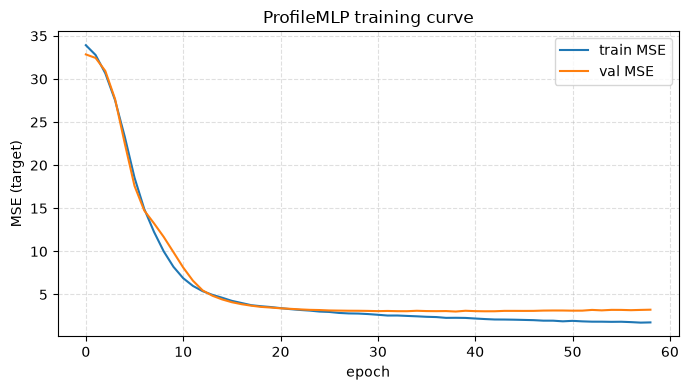

In [83]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_mlp["train_loss"], label="train MSE")
ax.plot(hist_mlp["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (target)")
ax.set_title("ProfileMLP training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


Held-out test set (43,776 variants): r(real target, MLP prediction) = 0.905


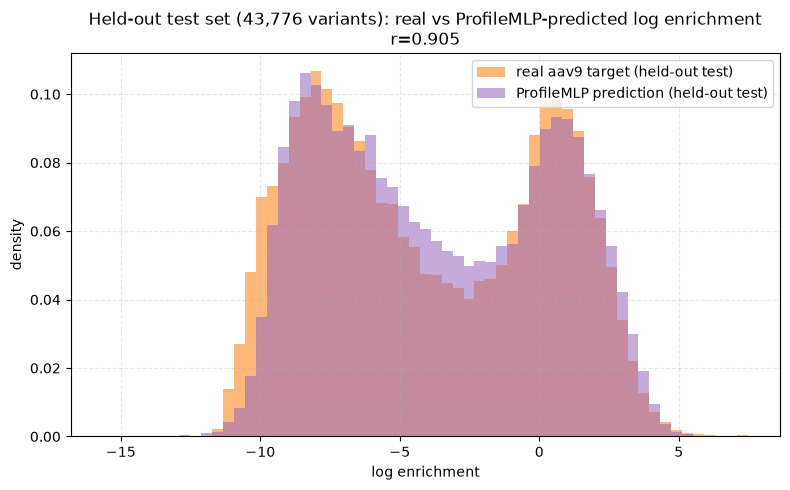

In [84]:
def batched_predict(model, X_oh, batch_size=8192):
    chunks = []
    for start in range(0, X_oh.shape[0], batch_size):
        chunk = jnp.asarray(X_oh[start : start + batch_size])
        chunks.append(np.asarray(predict_scores(model, chunk)))
    return np.concatenate(chunks)

pred_test_mlp = batched_predict(model_mlp, X_test_mlp)
r_test_mlp    = pearson(y_test_mlp, pred_test_mlp)
print(f"Held-out test set ({len(y_test_mlp):,} variants): r(real target, MLP prediction) = {r_test_mlp:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
bins_mlp = np.linspace(min(y_test_mlp.min(), pred_test_mlp.min()),
                        max(y_test_mlp.max(), pred_test_mlp.max()), 60)
ax.hist(y_test_mlp,    bins=bins_mlp, alpha=0.55, density=True, color="tab:orange", label="real aav9 target (held-out test)")
ax.hist(pred_test_mlp, bins=bins_mlp, alpha=0.55, density=True, color="tab:purple", label="ProfileMLP prediction (held-out test)")
ax.set_xlabel("log enrichment")
ax.set_ylabel("density")
ax.set_title(f"Held-out test set ({len(y_test_mlp):,} variants): real vs ProfileMLP-predicted log enrichment\n"
             f"r={r_test_mlp:.3f}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()
